In [2]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/datasets/meetnagadia/amazon-kindle-book-review-for-sentiment-analysis/all_kindle_review .csv
/kaggle/input/datasets/meetnagadia/amazon-kindle-book-review-for-sentiment-analysis/preprocessed_kindle_review .csv


In [3]:
# Loading Dataset
df = pd.read_csv('/kaggle/input/datasets/meetnagadia/amazon-kindle-book-review-for-sentiment-analysis/all_kindle_review .csv')

In [4]:
df.head()

,Unnamed: 0.1,Unnamed: 0,asin,helpful,rating,reviewText,reviewTime,reviewerID,reviewerName,summary,unixReviewTime
0,0,11539,B0033UV8HI,"[8, 10]",3,"Jace Rankin may be short, but he's nothing to ...","09 2, 2010",A3HHXRELK8BHQG,Ridley,Entertaining But Average,1283385600
1,1,5957,B002HJV4DE,"[1, 1]",5,Great short read. I didn't want to put it dow...,"10 8, 2013",A2RGNZ0TRF578I,Holly Butler,Terrific menage scenes!,1381190400
2,2,9146,B002ZG96I4,"[0, 0]",3,I'll start by saying this is the first of four...,"04 11, 2014",A3S0H2HV6U1I7F,Merissa,Snapdragon Alley,1397174400
3,3,7038,B002QHWOEU,"[1, 3]",3,Aggie is Angela Lansbury who carries pocketboo...,"07 5, 2014",AC4OQW3GZ919J,Cleargrace,very light murder cozy,1404518400
4,4,1776,B001A06VJ8,"[0, 1]",4,I did not expect this type of book to be in li...,"12 31, 2012",A3C9V987IQHOQD,Rjostler,Book,1356912000


In [5]:
# making new df with two important feature for snetiment analysis
df = df[['rating','reviewText']]

In [6]:
df.head()

,rating,reviewText
0,3,"Jace Rankin may be short, but he's nothing to ..."
1,5,Great short read. I didn't want to put it dow...
2,3,I'll start by saying this is the first of four...
3,3,Aggie is Angela Lansbury who carries pocketboo...
4,4,I did not expect this type of book to be in li...


In [7]:
# Checking for null values
df.isnull().sum()

rating        0
reviewText    0
dtype: int64

In [8]:
# Checking for distribution
df['rating'].value_counts()

rating
5    3000
4    3000
3    2000
2    2000
1    2000
Name: count, dtype: int64

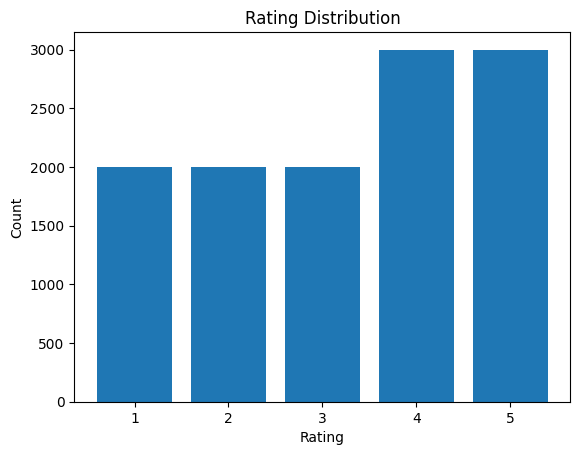

In [9]:
import matplotlib.pyplot as plt

rating_counts = df['rating'].value_counts().sort_index()

plt.figure()
plt.bar(rating_counts.index, rating_counts.values)
plt.xlabel("Rating")
plt.ylabel("Count")
plt.title("Rating Distribution")
plt.show()

### We are doing sentiment analysis, so we will be encoding rating into binary class.
### 1 will represent positive and 0 will represent negative

In [10]:
df['rating'] = df['rating'].apply(lambda x: 1 if x>3 else 0)

In [11]:
df['rating'].value_counts()

rating
0    6000
1    6000
Name: count, dtype: int64

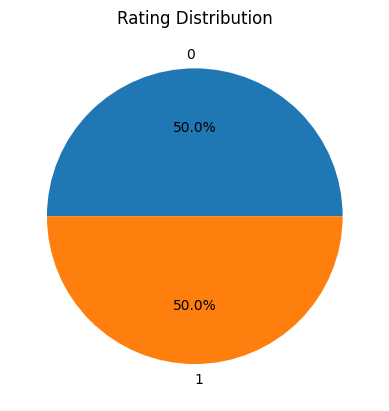

In [12]:
df['rating'].value_counts().plot(kind='pie', autopct='%1.1f%%')
plt.title("Rating Distribution")
plt.ylabel("")
plt.show()

## Preprocessing and cleaning

In [13]:
# Lowering all cases
df['reviewText'] = df['reviewText'].str.lower()



In [14]:
df['reviewText']

0        jace rankin may be short, but he's nothing to ...
1        great short read.  i didn't want to put it dow...
2        i'll start by saying this is the first of four...
3        aggie is angela lansbury who carries pocketboo...
4        i did not expect this type of book to be in li...
                               ...                        
11995    valentine cupid is a vampire- jena and ian ano...
11996    i have read all seven books in this series. ap...
11997    this book really just wasn't my cuppa.  the si...
11998    tried to use it to charge my kindle, it didn't...
11999    taking instruction is a look into the often hi...
Name: reviewText, Length: 12000, dtype: object

In [15]:
# Removing special Characters

import re

df['reviewText'] = df['reviewText'].str.replace(
    r'[^a-zA-Z0-9\s]',
    '',
    regex=True
)

In [16]:
# Renoving url
df['reviewText'] = df['reviewText'].str.replace(
    r'http\S+|www\S+|https\S+',
    '',
    regex=True
)

In [17]:
# Removing html tags
df['reviewText'] = df['reviewText'].str.replace(
    r'<.*?>',
    '',
    regex=True
)

In [18]:
# Removing extra spaces
df['reviewText'] = df['reviewText'].str.replace(
    r'\s+',
    ' ',
    regex=True
).str.strip()

In [19]:
df['reviewText']

0        jace rankin may be short but hes nothing to me...
1        great short read i didnt want to put it down s...
2        ill start by saying this is the first of four ...
3        aggie is angela lansbury who carries pocketboo...
4        i did not expect this type of book to be in li...
                               ...                        
11995    valentine cupid is a vampire jena and ian anot...
11996    i have read all seven books in this series apo...
11997    this book really just wasnt my cuppa the situa...
11998    tried to use it to charge my kindle it didnt e...
11999    taking instruction is a look into the often hi...
Name: reviewText, Length: 12000, dtype: object

In [20]:
# removing stop words
import nltk
from nltk.corpus import stopwords

# Downloading stopwords
nltk.download('stopwords')

stop_words = set(stopwords.words('english'))

df['reviewText'] = df['reviewText'].apply(
    lambda x: ' '.join(
        word for word in x.split()
        if word not in stop_words
    )
)

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


In [21]:
df['reviewText']

0        jace rankin may short hes nothing mess man hau...
1        great short read didnt want put read one sitti...
2        ill start saying first four books wasnt expect...
3        aggie angela lansbury carries pocketbooks inst...
4        expect type book library pleased find price right
                               ...                        
11995    valentine cupid vampire jena ian another vampi...
11996    read seven books series apocalypticadventure o...
11997    book really wasnt cuppa situation man capturin...
11998    tried use charge kindle didnt even register ch...
11999    taking instruction look often hidden world sex...
Name: reviewText, Length: 12000, dtype: object

In [22]:
# lemmatize
from nltk.stem import WordNetLemmatizer
nltk.download('wordnet')

lemmatizer = WordNetLemmatizer()

df['reviewText'] = df['reviewText'].apply(lambda x: ' '.join(lemmatizer.lemmatize(word) for word in x.split()))

[nltk_data] Downloading package wordnet to /usr/share/nltk_data...
[nltk_data]   Package wordnet is already up-to-date!


In [36]:
df.isnull().sum()

rating        0
reviewText    0
dtype: int64

# Train Test split

In [24]:
X = df['reviewText']
y=df['rating']

In [25]:
import sklearn
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y, test_size=0.20,random_state = 42)

In [34]:
X_train

9182     looking forward book came double space every p...
11091    already owned book spouse forgot already part ...
6428     cool forgot request rate came make mine unreli...
288      short short story basically scene party one ni...
2626     secret service agent secrests even longer serv...
                               ...                        
11964    downloaded book reading review usually reading...
5191     far one hottest book ive ever gotten hand ondo...
5390     even though book free reservation based majori...
860      little mushy 34must take care woman folk34 cha...
7270     book good good set charaterswith background le...
Name: reviewText, Length: 9600, dtype: object

# Applying different vectarization method

In [27]:
# Applying Bag of Word
from sklearn.feature_extraction.text import CountVectorizer
bow = CountVectorizer()
X_train_bow=bow.fit_transform(X_train).toarray()
X_test_bow = bow.transform(X_test).toarray()   #Prevents data leakage


In [37]:
X_train_bow

array([[0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0],
       [0, 0, 0, ..., 0, 0, 0]])

In [38]:
from sklearn.naive_bayes import GaussianNB
nb_model = GaussianNB()

from sklearn.metrics import confusion_matrix, accuracy_score, classification_report

In [39]:
nb_model_bow = nb_model.fit(X_train_bow,y_train)

In [40]:
y_pred_bow = nb_model_bow.predict(X_test_bow)

In [41]:
print("Bow Accuracy: ",accuracy_score(y_test,y_pred_bow))

Bow Accuracy:  0.59


In [42]:
# Applying TD-fit
from sklearn.feature_extraction.text import TfidfVectorizer
tdfit = TfidfVectorizer()
X_train_tdfit = tdfit.fit_transform(X_train).toarray()
X_test_tdfit = tdfit.transform (X_test).toarray()

In [43]:
#  For TF-IDF
nb_model_tfidf = nb_model.fit(X_train_tdfit,y_train)

In [44]:
y_pred_tfidf = nb_model_tfidf.predict(X_test_tdfit)

In [45]:
print("TFIDF Accuracy: ",accuracy_score(y_test,y_pred_tfidf))

TFIDF Accuracy:  0.6283333333333333


In [29]:
!pip install gensim

In [46]:
X_train

9182     looking forward book came double space every p...
11091    already owned book spouse forgot already part ...
6428     cool forgot request rate came make mine unreli...
288      short short story basically scene party one ni...
2626     secret service agent secrests even longer serv...
                               ...                        
11964    downloaded book reading review usually reading...
5191     far one hottest book ive ever gotten hand ondo...
5390     even though book free reservation based majori...
860      little mushy 34must take care woman folk34 cha...
7270     book good good set charaterswith background le...
Name: reviewText, Length: 9600, dtype: object

In [53]:
X_train_tokens = X_train.apply(lambda x: x.split())
X_test_tokens = X_test.apply(lambda x: x.split())

In [54]:
print(X_train_tokens.iloc[0])

['looking', 'forward', 'book', 'came', 'double', 'space', 'every', 'paragraph', 'kindle', 'edition', 'since', 'action', 'move', 'around', 'formatting', 'make', 'story', 'hard', 'follow', 'die', 'hard', 'like', 'want', 'botherits', 'sad', 'thing', 'good', 'book', 'spoiled', 'formatting', 'fault', 'author', 'story', 'good', 'book', 'energy', 'read', 'itive', 'also', 'emailed', 'author']


In [ ]:
from gensim.models import Word2Vec

w2v_mode = Word2Vec(
    sentences=X_train_tokens,
    vector_size=100,
    window=5,
    min_count=2,
    workers=4
)

In [ ]:
y_pred_w2v = w2v_mode.pred()

In [ ]:
# Applying TD-fit
from sklearn.feature_extraction.text import TfidfVectorizer
tdfit = TfidfVectorizer()
X_train_tdfit = tdfit.fit_transform(X_train).toarray()
X_test_tdfit = tdfit.transform (X_test).toarray()